### Generate data

In [6]:
import covasim as cv
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# The lines below are specific to the notebook format
%matplotlib inline
plt.rcParams["figure.figsize"] = (12, 6)

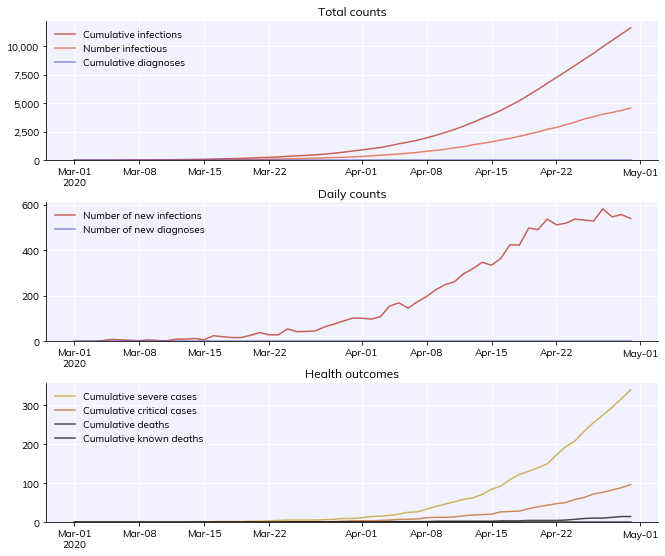

In [3]:
sim = cv.Sim(verbose=0)
sim.run().plot();

## One-dimensional sweep over beta

In [5]:
betas = np.logspace(-2.25, -1.25, 100)
sims = []
for i, beta in enumerate(betas):
    sim = cv.Sim(beta=beta, rand_seed=i, label=f'Beta = {beta}')
    sims.append(sim)
msim = cv.MultiSim(sims, reseed=True)
msim.run()

Initializing sim with 20000 people for 60 days
Initializing sim with 20000 people for 60 days
Initializing sim with 20000 people for 60 days
Initializing sim with 20000 people for 60 daysInitializing sim with 20000 people for 60 daysInitializing sim with 20000 people for 60 days


Initializing sim with 20000 people for 60 daysInitializing sim with 20000 people for 60 daysInitializing sim with 20000 people for 60 days

Initializing sim with 20000 people for 60 days

  Running "Beta = 0.005623413251903491": 2020-03-01 ( 0/60) (0.10 s)  ———————————————————— 2%
  Running "Beta = 0.006465558724388368": 2020-03-01 ( 0/60) (0.11 s)  ———————————————————— 2%
  Running "Beta = 0.0060298017058345935": 2020-03-01 ( 0/60) (0.11 s)  ———————————————————— 2%
  Running "Beta = 0.0091647624407065": 2020-03-01 ( 0/60) (0.11 s)  ———————————————————— 2%
  Running "Beta = 0.00854708812559251": 2020-03-01 ( 0/60) (0.12 s)  ———————————————————— 2%

  Running "Beta = 0.006932806692144524": 2020-03-01 ( 0/60) (

MultiSim("Beta = 0.005623413251903491"; n_sims: 100; base: Sim("Beta = 0.005623413251903491"; 2020-03-01 to 2020-04-30; pop: 20000 random; epi: not run))

,log_beta,cum_inf
0,-2.250000,290.0
1,-2.239899,215.0
2,-2.229798,367.0
3,-2.219697,53.0
4,-2.209596,113.0
...,...,...
95,-1.290404,28676.0
96,-1.280303,29965.0
97,-1.270202,30126.0
98,-1.260101,29989.0


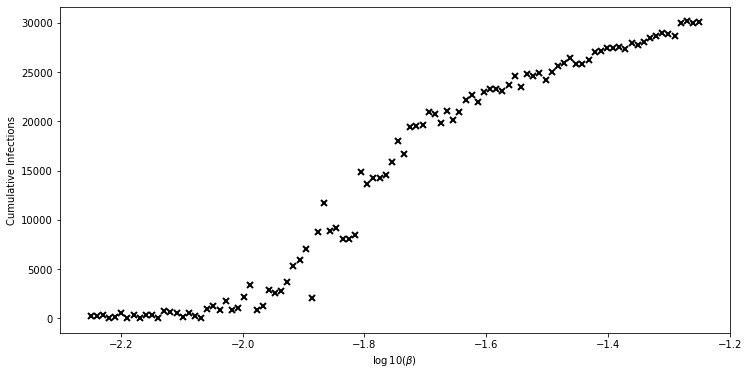

In [11]:
X = np.array(np.log10([s.pars['beta'] for s in msim.sims]))
Y = np.array([s.results['cum_infections'][-1] for s in msim.sims])

df = pd.DataFrame({'log_beta': X, 'cum_inf': Y})
display(df)
df.to_csv('beta_sweep.csv')

f, ax = plt.subplots();
ax.plot(X, Y, 'kx', mew=2);
ax.set_xlabel(r'$\log10(\beta$)');
ax.set_ylabel('Cumulative Infections');